# 1. starfold — quickstart

The 30-second story: give `starfold` any numerical feature matrix and
it will return a 2-D embedding, cluster labels, and a handful of
quality scores.

This notebook fits the full pipeline on a **closed chain of eight
Hopf-linked tori in 3-D** — a synthetic point cloud with rich local
topology but no domain baggage. The point here is to prove the tool
runs end-to-end; notebooks 2, 3, and 4 cover validation, refinement,
and a real-data case study respectively.

In [1]:
from __future__ import annotations

import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# The torus generator is example code, not part of the installed package.
sys.path.insert(0, str(Path.cwd().parent / "examples"))
from torus_chain import make_torus_chain  # noqa: E402

import starfold as sf  # noqa: E402

FIGURE_DIR = Path("figures") / "tutorial_01_quickstart"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 150,
    "savefig.bbox": "tight",
    "font.size": 11,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

print(f"starfold {sf.__version__}")
print(f"cuml importable: {sf.cuml_is_importable()}")

starfold 0.0.1


cuml importable: True


## 1.1 Build the dataset

Eight tori, 600 points each (4 800 samples, three features). Adjacent
tori are Hopf-linked through each other's holes; non-adjacent tori
are not. Every torus is topologically a circle, so UMAP cannot embed
it in 2-D without tearing — each ring typically shows up as one or
two arcs in the output.

In [2]:
X, y_true = make_torus_chain(
    n_links=8,
    points_per_link=600,
    big_radius=4.0,
    major_even=2.0,
    major_odd=2.5,
    minor_radius=0.15,
    solid=True,
    noise_std=0.02,
    random_state=0,
)
print(f"X.shape      = {X.shape}")
print(f"unique labels= {np.unique(y_true)}")

X.shape      = (4800, 3)
unique labels= [0 1 2 3 4 5 6 7]


### A quick look at the chain

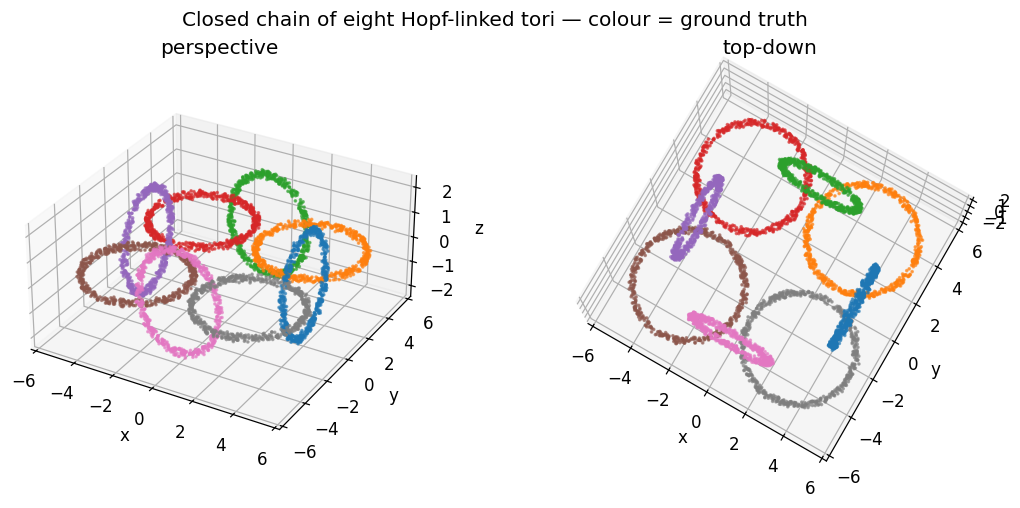

In [3]:
fig = plt.figure(figsize=(10, 4.5), constrained_layout=True)
for i, (elev, azim, title) in enumerate([(30, -60, "perspective"),
                                          (80, -60, "top-down")]):
    ax = fig.add_subplot(1, 2, i + 1, projection="3d")
    ax.view_init(elev=elev, azim=azim)
    cmap = plt.get_cmap("tab10")
    for k in range(8):
        m = y_true == k
        ax.scatter(X[m, 0], X[m, 1], X[m, 2], s=2.0, color=cmap(k), alpha=0.6)
    ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")
    ax.set_title(title)
    ax.set_box_aspect((1, 1, 0.5))
fig.suptitle("Closed chain of eight Hopf-linked tori — colour = ground truth")
fig.savefig(FIGURE_DIR / "01_torus_chain_3d.png")
plt.show()

## 1.2 Fit the pipeline

One call runs

    StandardScaler → UMAP → Optuna-tuned HDBSCAN → trustworthiness + continuity

The noise baseline is skipped here (tutorial 2 covers it in detail).
The Optuna budget is deliberately small — 30 trials is enough on a
clean synthetic dataset and keeps the wall-clock short.

In [4]:
pipeline = sf.UnsupervisedPipeline(
    umap_kwargs={"n_epochs": 500, "n_neighbors": 30, "min_dist": 0.0},
    hdbscan_optuna_trials=30,
    mcs_range=(100, 800),
    ms_range=(5, 30),
    engine="auto",
    skip_noise_baseline=True,
    random_state=0,
)
t0 = time.perf_counter()
result = pipeline.fit(X)
print(f"pipeline.fit took {time.perf_counter() - t0:.1f}s")
print()
print(result.summary())

[2026-04-22 17:09:07.983] [CUML] [info] build_algo set to brute_force_knn because random_state is given


pipeline.fit took 16.1s

starfold pipeline result
--------------------------------
n_samples        4800
n_clusters       22
n_outliers       394  (8.2%)
trustworthiness  0.9983
continuity       0.9987
objective        persistence_sum
best_params      {'min_cluster_size': 113, 'min_samples': 11, 'cluster_selection_method': 'leaf', 'cluster_selection_epsilon': 0.19854474214308276, 'alpha': 1.390558449490858}
persistence_sum  6.1418
persistence_med  0.2668
DBCV (MST proxy) 0.4129
persistence      [0.246 0.487 0.281 0.101 0.136 0.424 0.065 0.264 0.409 0.351 0.538 0.313
 0.215 0.527 0.164 0.317 0.233 0.27  0.102 0.42  0.246 0.035]


## 1.3 What came out

Left: the 2-D UMAP embedding, coloured by HDBSCAN label (outliers in
grey). Right: the original 3-D chain re-coloured by predicted
cluster. Any torus that was split into two arcs in the embedding
will show up as two colours on the same ring in 3-D.

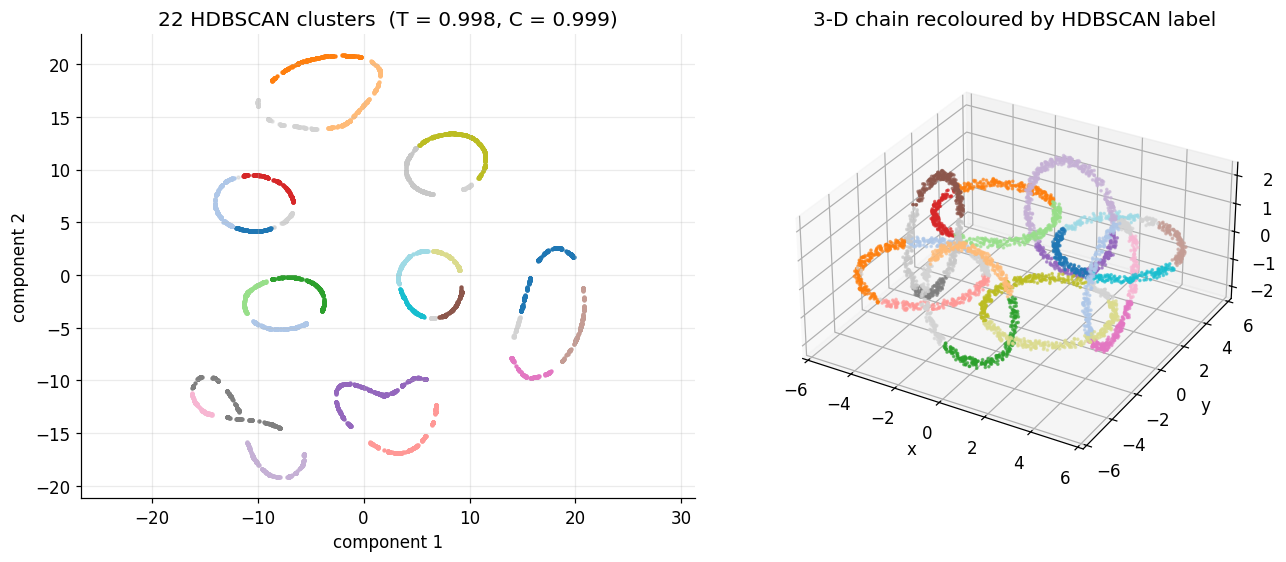

In [5]:
fig = plt.figure(figsize=(12, 5.0), constrained_layout=True)

ax_emb = fig.add_subplot(121)
sf.plot_embedding(result.embedding, result.labels, ax=ax_emb,
                  point_size=3.5, cmap="tab20")
ax_emb.set_title(
    f"{result.n_clusters} HDBSCAN clusters  "
    f"(T = {result.trustworthiness:.3f}, C = {result.continuity:.3f})"
)

ax_pred = fig.add_subplot(122, projection="3d")
ax_pred.view_init(elev=30, azim=-60)
cmap = plt.get_cmap("tab20")
uniq = sorted({int(k) for k in result.labels.tolist()})
for k in uniq:
    m = result.labels == k
    colour = "lightgrey" if k == -1 else cmap(uniq.index(k) % 20)
    ax_pred.scatter(X[m, 0], X[m, 1], X[m, 2], s=2.0, color=colour, alpha=0.6)
ax_pred.set_xlabel("x"); ax_pred.set_ylabel("y"); ax_pred.set_zlabel("z")
ax_pred.set_title(f"3-D chain recoloured by HDBSCAN label")
ax_pred.set_box_aspect((1, 1, 0.5))

fig.savefig(FIGURE_DIR / "02_embedding_and_3d.png")
plt.show()

## 1.4 What lives on the result

`PipelineResult` bundles everything the pipeline produced. The
attributes most users want are:

| attribute | shape / type | notes |
|---|---|---|
| `embedding` | `(n_samples, 2)` | the 2-D UMAP output |
| `labels` | `(n_samples,)` | HDBSCAN cluster IDs, `-1` = outlier |
| `persistence` | `(n_clusters,)` | HDBSCAN cluster persistence |
| `trustworthiness` | `float` in `[0, 1]` | Venna & Kaski (2001) |
| `continuity` | `float` in `[0, 1]` | complementary score |
| `best_params` | `dict` | selected HDBSCAN hyperparameters |
| `flags` | `list[str]` | diagnostic warnings, empty on a clean fit |

And everything needed to reproduce or persist the run:

```python
result.save("run_01/")                 # disk snapshot
loaded = sf.load_pipeline_result("run_01/")
```

In [6]:
print(f"outliers:            {int(np.sum(result.labels == -1))} / {len(X)}")
print(f"best HDBSCAN params: {result.best_params}")
print(f"flags:               {result.flags or 'none'}")

outliers:            394 / 4800
best HDBSCAN params: {'min_cluster_size': 113, 'min_samples': 11, 'cluster_selection_method': 'leaf', 'cluster_selection_epsilon': 0.19854474214308276, 'alpha': 1.390558449490858}
flags:               none


## Next

* **[2. Validation](tutorial_02_validation.ipynb)** — is any of this
  above what noise would produce? Runs the 99.7 % noise baseline,
  the 3σ credibility test, and the two one-line dashboards.
* **[3. Refinement](tutorial_03_advanced.ipynb)** — silhouette,
  merge recommendations, sub-cluster refit, input-uncertainty
  propagation.
* **[4. Astronomy case study](tutorial_04_astronomy.ipynb)** — the
  same pipeline on 9 242 real Milky Way stars.